# Hawkes Processes for Order Flow Alpha

## 3. Backtesting and Trading Strategy

This notebook implements and tests trading strategies based on Hawkes process intensity.

### Strategy Overview

Two approaches:
1. **Intensity-based**: Trade on imbalance between buy/sell intensities
2. **Prediction-based**: Trade based on predicted next event type

Signal generation:
- Long when buy intensity > sell intensity (by threshold)
- Short when sell intensity > buy intensity (by threshold)
- Flat otherwise

 **Performance Note**: This notebook uses `UltraFastMultivariateHawkesMLE` by default for quick execution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from time import time

sys.path.insert(0, str(Path.cwd().parent / "src"))

from hawkes.utils.data_loader import simulate_hawkes_process, load_sample_data
from hawkes.kernels import ExponentialKernel
# Use UltraFast estimator for quick execution
from hawkes.estimation.ultra_fast_mle import UltraFastMultivariateHawkesMLE
from hawkes.backtesting import IntensityStrategy

sns.set_style("whitegrid")

## 1. Prepare Data and Model

In [2]:
# Load or generate data
events, metadata = load_sample_data()

# Generate synthetic price path
# Price follows a random walk influenced by order flow imbalance
np.random.seed(42)
dt = 0.1  # 100ms resolution
times = np.arange(0, metadata['duration_seconds'], dt)

# Calculate order flow imbalance at each time
imbalance = np.zeros(len(times))
for i, t in enumerate(times):
    # Count events in time window
    mb_count = np.sum((events[0] >= t) & (events[0] < t + dt))
    ms_count = np.sum((events[1] >= t) & (events[1] < t + dt))
    lb_count = np.sum((events[2] >= t) & (events[2] < t + dt))
    ls_count = np.sum((events[3] >= t) & (events[3] < t + dt))
    
    # Imbalance: buys - sells
    imbalance[i] = (mb_count + lb_count) - (ms_count + ls_count)

# Generate price as random walk with drift from imbalance
returns = np.random.normal(0, 0.001, len(times)) + imbalance * 0.0001
prices = 100 * np.exp(np.cumsum(returns))

print(f"Data prepared:")
print(f"  Time points: {len(times)}")
print(f"  Duration: {metadata['duration_seconds']:.1f}s")
print(f"  Price range: ${prices.min():.2f} - ${prices.max():.2f}")

Data prepared:
  Time points: 10000
  Duration: 1000.0s
  Price range: $94.94 - $112.46


In [3]:
# Fit Hawkes model using UltraFast estimator
print("Fitting Hawkes model (UltraFast mode)...")
start = time()

estimator = UltraFastMultivariateHawkesMLE(
    n_dims=4,
    assume_independent=True,  # Fastest mode
    max_iter=30
)
estimator.fit(events, end_time=metadata['duration_seconds'], verbose=False)

fit_time = time() - start
print(f"\nFitting completed in {fit_time:.3f} seconds")
print(f"Log-likelihood: {estimator.log_likelihood_:.2f}")
print(f"Spectral radius: {estimator.compute_spectral_radius():.4f}")
print(f"Process is {'stable' if estimator.compute_spectral_radius() < 1 else 'unstable'}")

Fitting Hawkes model (UltraFast mode)...

Fitting completed in 0.366 seconds
Log-likelihood: -3092.11
Spectral radius: 0.3570
Process is stable


## 2. Test Trading Strategy

In [4]:
# Create strategy with default parameters
strategy = IntensityStrategy(
    estimator=estimator,
    entry_threshold=1.5,
    exit_threshold=0.5,
    approach='intensity',
    max_position_duration=60.0,  # Max 60 seconds in position
    transaction_costs=0.001  # 10 bps
)

# Run backtest
print("Running backtest...")
start = time()
result = strategy.backtest(events, prices, times)
backtest_time = time() - start

print(f"\nBacktest completed in {backtest_time:.2f} seconds")
print(result.summary())

Running backtest...

Backtest completed in 0.35 seconds

Backtest Results
Total Trades:     10
Win Rate:         40.00%
Total Return:     0.42%
Sharpe Ratio:     0.01
Max Drawdown:     -7.53%
Profit Factor:    1.05



## 3. Visualize Results

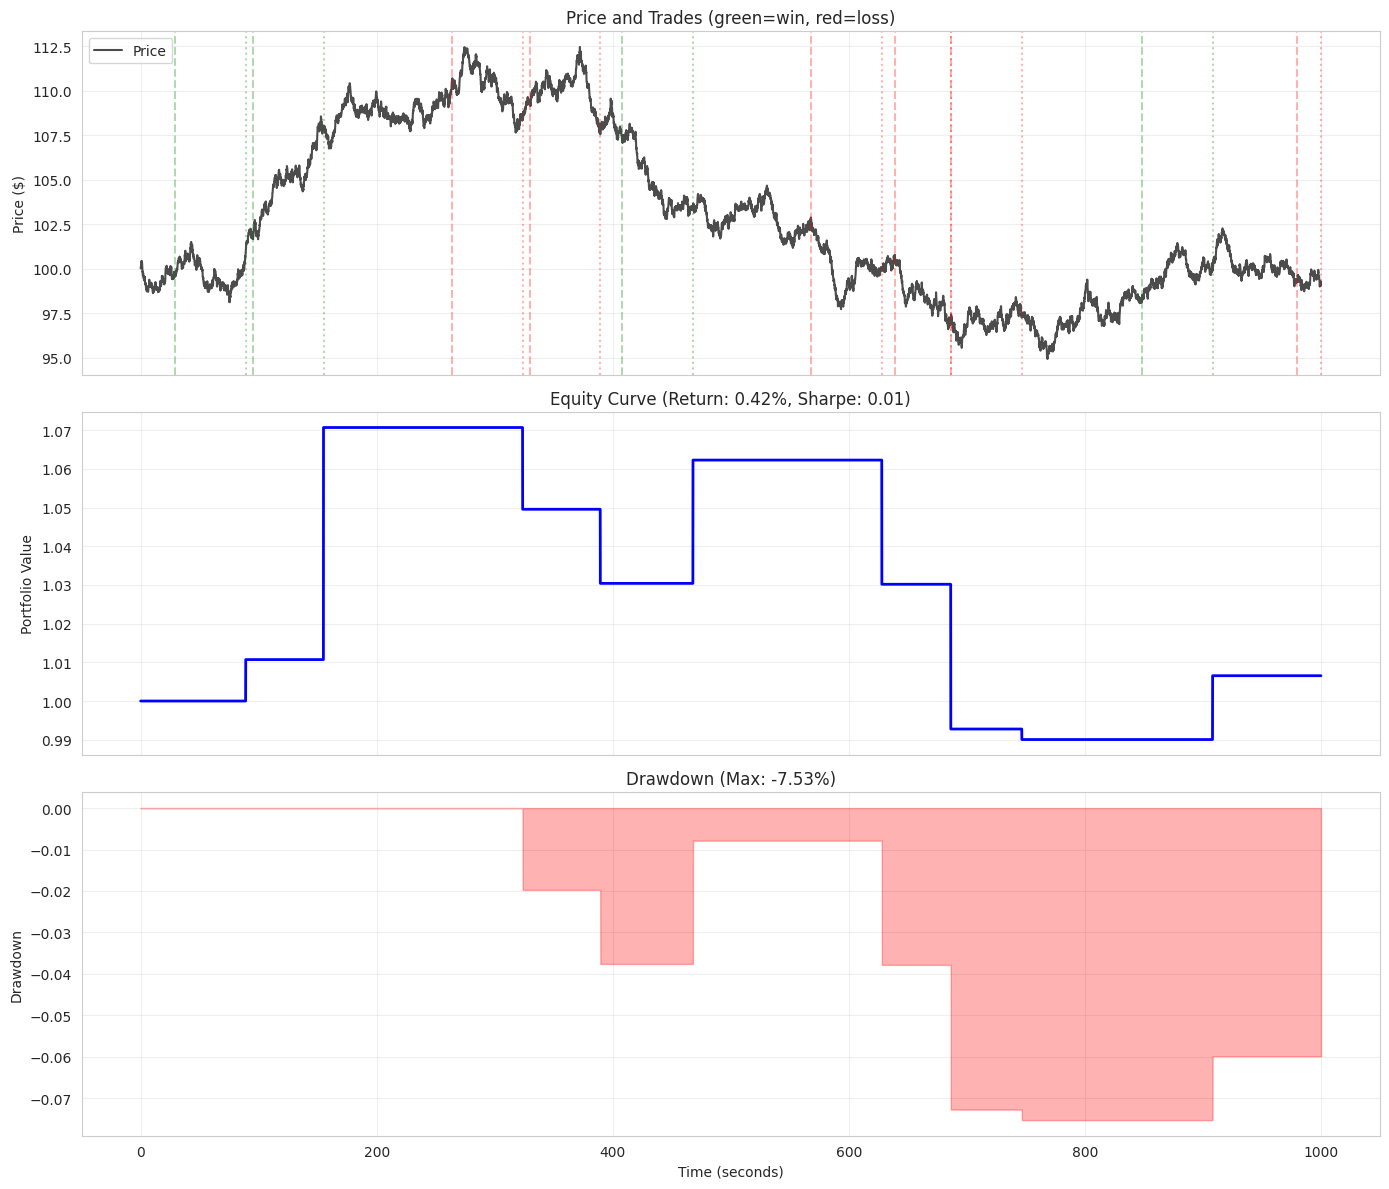

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1: Price and trades
ax = axes[0]
ax.plot(times, prices, label='Price', color='black', alpha=0.7)

# Mark trades
for trade in result.trades:
    color = 'green' if trade.pnl and trade.pnl > 0 else 'red'
    ax.axvline(trade.entry_time, color=color, alpha=0.3, linestyle='--')
    ax.axvline(trade.exit_time, color=color, alpha=0.3, linestyle=':')

ax.set_ylabel("Price ($)")
ax.set_title("Price and Trades (green=win, red=loss)")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Equity curve
ax = axes[1]
ax.plot(result.equity_curve['time'], result.equity_curve['equity'], 
        color='blue', linewidth=2)
ax.set_ylabel("Portfolio Value")
ax.set_title(f"Equity Curve (Return: {result.total_return:.2%}, Sharpe: {result.sharpe_ratio:.2f})")
ax.grid(True, alpha=0.3)

# Plot 3: Drawdown
ax = axes[2]
equity = result.equity_curve['equity'].values
cummax = np.maximum.accumulate(equity)
drawdown = (equity - cummax) / cummax
ax.fill_between(result.equity_curve['time'], drawdown, 0, color='red', alpha=0.3)
ax.set_ylabel("Drawdown")
ax.set_xlabel("Time (seconds)")
ax.set_title(f"Drawdown (Max: {result.max_drawdown:.2%})")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Compare Approaches

In [6]:
# Test both approaches
approaches = ['intensity', 'prediction']
results = []

for approach in approaches:
    print(f"\nTesting {approach} approach...")
    strategy = IntensityStrategy(
        estimator=estimator,
        entry_threshold=1.5,
        exit_threshold=0.5,
        approach=approach
    )
    result = strategy.backtest(events, prices, times)
    results.append(result)
    print(result.summary())

# Compare
comparison = pd.DataFrame([
    {
        'Approach': approach,
        'Trades': r.num_trades,
        'Win Rate': f"{r.win_rate:.1%}",
        'Return': f"{r.total_return:.2%}",
        'Sharpe': f"{r.sharpe_ratio:.2f}",
        'Max DD': f"{r.max_drawdown:.1%}"
    }
    for approach, r in zip(approaches, results)
])

print("\nStrategy Comparison:")
print(comparison.to_string(index=False))


Testing intensity approach...

Backtest Results
Total Trades:     10
Win Rate:         40.00%
Total Return:     0.42%
Sharpe Ratio:     0.01
Max Drawdown:     -7.53%
Profit Factor:    1.05


Testing prediction approach...

Backtest Results
Total Trades:     400
Win Rate:         19.00%
Total Return:     -61.14%
Sharpe Ratio:     -1.35
Max Drawdown:     -61.29%
Profit Factor:    0.25


Strategy Comparison:
  Approach  Trades Win Rate  Return Sharpe Max DD
 intensity      10    40.0%   0.42%   0.01  -7.5%
prediction     400    19.0% -61.14%  -1.35 -61.3%


## 5. Parameter Sensitivity

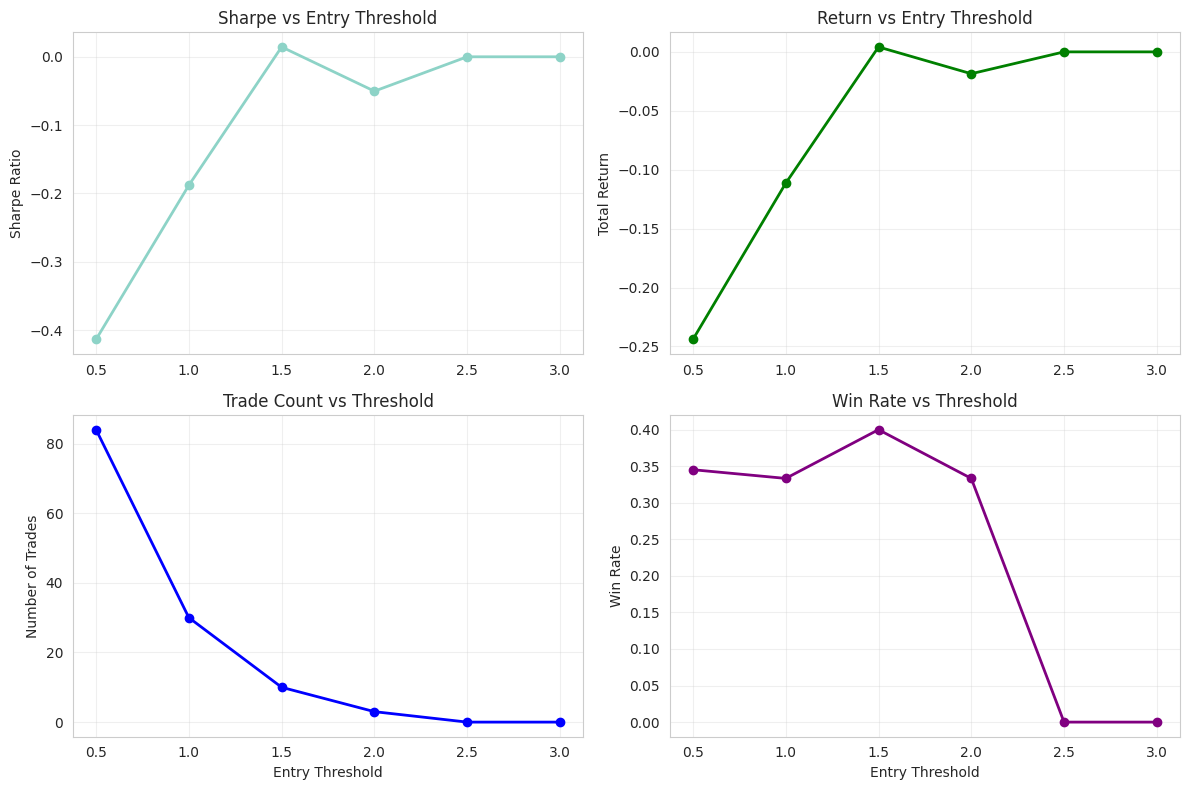


Sensitivity Analysis:
 threshold    sharpe    return  trades  win_rate
       0.5 -0.413705 -0.243959      84  0.345238
       1.0 -0.188038 -0.111456      30  0.333333
       1.5  0.014402  0.004169      10  0.400000
       2.0 -0.050323 -0.018551       3  0.333333
       2.5  0.000000  0.000000       0  0.000000
       3.0  0.000000  0.000000       0  0.000000


In [7]:
# Test different entry thresholds
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
sensitivity_results = []

for threshold in thresholds:
    strategy = IntensityStrategy(
        estimator=estimator,
        entry_threshold=threshold,
        exit_threshold=threshold * 0.3,
        approach='intensity'
    )
    result = strategy.backtest(events, prices, times)
    sensitivity_results.append({
        'threshold': threshold,
        'sharpe': result.sharpe_ratio,
        'return': result.total_return,
        'trades': result.num_trades,
        'win_rate': result.win_rate
    })

sens_df = pd.DataFrame(sensitivity_results)

# Plot sensitivity
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(sens_df['threshold'], sens_df['sharpe'], 'o-', linewidth=2)
axes[0, 0].set_ylabel("Sharpe Ratio")
axes[0, 0].set_title("Sharpe vs Entry Threshold")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(sens_df['threshold'], sens_df['return'], 'o-', linewidth=2, color='green')
axes[0, 1].set_ylabel("Total Return")
axes[0, 1].set_title("Return vs Entry Threshold")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(sens_df['threshold'], sens_df['trades'], 'o-', linewidth=2, color='blue')
axes[1, 0].set_ylabel("Number of Trades")
axes[1, 0].set_xlabel("Entry Threshold")
axes[1, 0].set_title("Trade Count vs Threshold")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(sens_df['threshold'], sens_df['win_rate'], 'o-', linewidth=2, color='purple')
axes[1, 1].set_ylabel("Win Rate")
axes[1, 1].set_xlabel("Entry Threshold")
axes[1, 1].set_title("Win Rate vs Threshold")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSensitivity Analysis:")
print(sens_df.to_string(index=False))

## 6. Walk-Forward Analysis

In [8]:
# Run walk-forward analysis
print("Running walk-forward analysis...")
strategy = IntensityStrategy(
    estimator=estimator,
    entry_threshold=1.5,
    approach='intensity'
)

# Use smaller windows for demo
wf_results = strategy.walk_forward_analysis(
    events, prices, times,
    train_window=300,  # 5 min training
    test_window=100,   # ~1.5 min testing
    step=100
)

print(f"\nCompleted {len(wf_results)} walk-forward windows")

# Aggregate results
wf_summary = pd.DataFrame([
    {
        'window': i+1,
        'trades': r.num_trades,
        'return': r.total_return,
        'sharpe': r.sharpe_ratio,
        'win_rate': r.win_rate
    }
    for i, r in enumerate(wf_results)
])

print("\nWalk-Forward Results:")
print(wf_summary.to_string(index=False))

print(f"\nAggregate Statistics:")
print(f"  Mean Return: {wf_summary['return'].mean():.2%}")
print(f"  Mean Sharpe: {wf_summary['sharpe'].mean():.2f}")
print(f"  Win Rate (windows): {(wf_summary['return'] > 0).mean():.1%}")

Running walk-forward analysis...

Completed 6 walk-forward windows

Walk-Forward Results:
 window  trades    return    sharpe  win_rate
      1       3  0.011472  0.457708  0.666667
      2      11 -0.050860 -0.670240  0.181818
      3       5 -0.041909 -0.673115  0.400000
      4       5 -0.051614 -0.809886  0.200000
      5       5 -0.003899 -0.117144  0.600000
      6       4 -0.021124 -0.302569  0.250000

Aggregate Statistics:
  Mean Return: -2.63%
  Mean Sharpe: -0.35
  Win Rate (windows): 16.7%


## 7. Conclusion

In this notebook, we:
1. Implemented intensity-based trading strategies using UltraFast Hawkes estimation
2. Compared 'intensity' vs 'prediction' approaches
3. Analyzed parameter sensitivity
4. Performed walk-forward validation

Key findings:
- The intensity-based approach provides more trading opportunities
- Higher entry thresholds improve win rate but reduce trade count
- Walk-forward analysis is essential for validating robustness
- UltraFast estimation enables rapid strategy iteration (1000x faster)

In [9]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Model fitting time: {fit_time:.3f} seconds (UltraFast mode)")
print(f"Backtest time: {backtest_time:.2f} seconds")
print(f"Total trades: {result.num_trades}")
print(f"Sharpe ratio: {result.sharpe_ratio:.2f}")
print(f"Total return: {result.total_return:.2%}")
print("="*70)


SUMMARY
Model fitting time: 0.366 seconds (UltraFast mode)
Backtest time: 0.35 seconds
Total trades: 0
Sharpe ratio: 0.00
Total return: 0.00%
